# Best model + safe geometric augmentation

In this experiment we retrain the best ConvNeXt-like model using
only geometry-preserving augmentations:

- 90 degree rotations
- horizontal reflections
- vertical reflections

These transformations do not change the Einstein radius and therefore
are physically safe for this regression task.


In [30]:
import os
import random
import time
from collections import defaultdict

import h5py
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score



In [31]:
H5_PATH = "roman_data_challenge_rung_0_v_1_0.h5"

SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

PIXEL_SCALE = 0.11
N_BINS = 8

# best model setup
BATCH_SIZE = 32
DROPOUT = 0.2
WEIGHT_DECAY = 3e-4
MAX_LR = 1e-3
EPOCHS = 250
TARGET_TRANSFORM = "log"
NORMALIZATION_MODE = "none"
LOSS_NAME = "huber"
TRAIN_MODE = "balanced_bins"

print("DEVICE:", DEVICE)


DEVICE: cuda


In [32]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)


In [33]:
def safe_float_attr(attrs, key):
    return float(attrs[key][0])

def load_system(group):
    uid = group.attrs["uid"][0]
    theta_e = safe_float_attr(group.attrs, "theta_e")

    r = group[f"exposure_{uid}_F158"][:].astype(np.float32)
    g = group[f"exposure_{uid}_F129"][:].astype(np.float32)
    b = group[f"exposure_{uid}_F106"][:].astype(np.float32)

    x = np.stack([r, g, b], axis=-1)
    return x, theta_e

def make_target_bins(y, n_bins=8):
    edges = np.quantile(y, np.linspace(0, 1, n_bins + 1))
    edges = np.unique(edges)
    bins = np.digitize(y, edges[1:-1], right=True)
    return bins, edges

def apply_target_transform(y, mode):
    if mode == "none":
        return y
    elif mode == "log":
        return np.log(y)
    else:
        raise ValueError(mode)

def invert_target_transform(y, mode):
    if mode == "none":
        return y
    elif mode == "log":
        return np.exp(y)
    else:
        raise ValueError(mode)

def regression_metrics(y_true, y_pred):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    r2 = float(r2_score(y_true, y_pred))
    return {"rmse": rmse, "mae": mae, "r2": r2}

def relative_error_stats(y_true, y_pred, eps=1e-8):
    rel = np.abs(y_pred - y_true) / np.maximum(np.abs(y_true), eps)
    return {
        "mean_relative_error": float(rel.mean()),
        "median_relative_error": float(np.median(rel)),
    }


In [34]:
f = h5py.File(H5_PATH, "r")
images_group = f["images"]
all_keys = list(images_group.keys())

X_list, y_list = [], []
for k in all_keys:
    x, y = load_system(images_group[k])
    X_list.append(x)
    y_list.append(y)

X = np.stack(X_list).astype(np.float32)
y = np.array(y_list, dtype=np.float32)

print("X:", X.shape)
print("y:", y.shape)
print("theta_E range:", y.min(), y.max())


X: (11160, 91, 91, 3)
y: (11160,)
theta_E range: 0.13509311 3.8531556


In [35]:
y_bins, bin_edges = make_target_bins(y, n_bins=N_BINS)
idx_all = np.arange(len(X))

idx_train, idx_tmp, yb_train, yb_tmp = train_test_split(
    idx_all, y_bins, test_size=0.30, random_state=SEED, stratify=y_bins
)

idx_val, idx_test, yb_val, yb_test = train_test_split(
    idx_tmp, yb_tmp, test_size=0.50, random_state=SEED, stratify=yb_tmp
)

print(len(idx_train), len(idx_val), len(idx_test))


7812 1674 1674


In [36]:
def safe_geometric_augment(x):
    # x: (H,W,C)
    k = np.random.randint(0, 4)   # 0,1,2,3 -> rotations of 90 deg
    x = np.rot90(x, k, axes=(0,1)).copy()

    if np.random.rand() < 0.5:
        x = np.flip(x, axis=0).copy()

    if np.random.rand() < 0.5:
        x = np.flip(x, axis=1).copy()

    return x


In [37]:
class RomanDataset(Dataset):
    def __init__(self, X, y, indices, augment=False,
                 target_transform="none",
                 normalization_mode="none",
                 channel_mean=None, channel_std=None):
        self.X = X
        self.y = y
        self.indices = indices
        self.augment = augment
        self.target_transform = target_transform
        self.normalization_mode = normalization_mode
        self.channel_mean = channel_mean
        self.channel_std = channel_std

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]
        x = self.X[idx].copy()
        yt = self.y[idx].astype(np.float32)

        if self.augment:
            x = safe_geometric_augment(x)

        x = np.log1p(x)

        if self.normalization_mode == "global_standard":
            x = (x - self.channel_mean[0]) / self.channel_std[0]
        elif self.normalization_mode == "per_image_max":
            x = x / (np.max(np.abs(x)) + 1e-8)
        elif self.normalization_mode == "none":
            pass
        else:
            raise ValueError(self.normalization_mode)

        x = np.transpose(x, (2,0,1)).astype(np.float32)

        yt_t = apply_target_transform(np.array([yt], dtype=np.float32), self.target_transform)[0]

        return torch.tensor(x), torch.tensor([yt_t], dtype=torch.float32), idx


In [38]:
def make_balanced_sampler(indices, y_bins):
    train_bins = y_bins[indices]
    counts = np.bincount(train_bins)
    bin_weights = 1.0 / np.maximum(counts, 1)
    sample_weights = bin_weights[train_bins]
    sample_weights = sample_weights / sample_weights.mean()

    sampler = WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(sample_weights),
        replacement=True
    )
    return sampler, bin_weights


In [39]:
train_ds = RomanDataset(
    X, y, idx_train,
    augment=True,
    target_transform=TARGET_TRANSFORM,
    normalization_mode=NORMALIZATION_MODE
)

val_ds = RomanDataset(
    X, y, idx_val,
    augment=False,
    target_transform=TARGET_TRANSFORM,
    normalization_mode=NORMALIZATION_MODE
)

test_ds = RomanDataset(
    X, y, idx_test,
    augment=False,
    target_transform=TARGET_TRANSFORM,
    normalization_mode=NORMALIZATION_MODE
)

sampler, bin_weights = make_balanced_sampler(idx_train, y_bins)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

len(train_ds), len(val_ds), len(test_ds)



(7812, 1674, 1674)

In [40]:
class TanhDepthwiseBlock(nn.Module):
    def __init__(self, c, dropout=0.0):
        super().__init__()
        self.dw = nn.Conv2d(c, c, 7, padding=3, groups=c, bias=False)
        self.bn1 = nn.BatchNorm2d(c)
        self.pw1 = nn.Conv2d(c, 4 * c, 1)
        self.pw2 = nn.Conv2d(4 * c, c, 1)
        self.act = nn.Tanh()
        self.dropout = nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()

    def forward(self, x):
        h = self.dw(x)
        h = self.bn1(h)
        h = self.act(h)
        h = self.pw1(h)
        h = self.act(h)
        h = self.dropout(h)
        h = self.pw2(h)
        return self.act(x + h)

class TanhConvNeXtMini(nn.Module):
    def __init__(self, in_ch=3, width=32, dropout=0.2):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(in_ch, width, 4, stride=2, padding=1),
            nn.BatchNorm2d(width),
            nn.Tanh(),
        )

        self.stage1 = nn.Sequential(
            TanhDepthwiseBlock(width, dropout=0.0),
            TanhDepthwiseBlock(width, dropout=0.0),
        )

        self.down2 = nn.Sequential(
            nn.Conv2d(width, 2 * width, 2, stride=2),
            nn.BatchNorm2d(2 * width),
            nn.Tanh(),
        )
        self.stage2 = nn.Sequential(
            TanhDepthwiseBlock(2 * width, dropout=0.0),
            TanhDepthwiseBlock(2 * width, dropout=0.0),
        )

        self.down3 = nn.Sequential(
            nn.Conv2d(2 * width, 4 * width, 2, stride=2),
            nn.BatchNorm2d(4 * width),
            nn.Tanh(),
        )
        self.stage3 = nn.Sequential(
            TanhDepthwiseBlock(4 * width, dropout=0.0),
            TanhDepthwiseBlock(4 * width, dropout=0.0),
        )

        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(4 * width, 128),
            nn.Tanh(),
            nn.Dropout(dropout),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.down2(x)
        x = self.stage2(x)
        x = self.down3(x)
        x = self.stage3(x)
        return self.head(x)

model = TanhConvNeXtMini(dropout=DROPOUT).to(DEVICE)
print(model)


TanhConvNeXtMini(
  (stem): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): Tanh()
  )
  (stage1): Sequential(
    (0): TanhDepthwiseBlock(
      (dw): Conv2d(32, 32, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=32, bias=False)
      (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (pw1): Conv2d(32, 128, kernel_size=(1, 1), stride=(1, 1))
      (pw2): Conv2d(128, 32, kernel_size=(1, 1), stride=(1, 1))
      (act): Tanh()
      (dropout): Identity()
    )
    (1): TanhDepthwiseBlock(
      (dw): Conv2d(32, 32, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=32, bias=False)
      (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (pw1): Conv2d(32, 128, kernel_size=(1, 1), stride=(1, 1))
      (pw2): Conv2d(128, 32, kernel_size=(1, 1), stride=(1, 1

In [41]:
def get_bin_weight_for_targets(targets_original, bin_edges, bin_weights):
    y_np = targets_original.detach().cpu().numpy().reshape(-1)
    bins = np.digitize(y_np, bin_edges[1:-1], right=True)
    w = bin_weights[bins]
    return torch.tensor(w, dtype=torch.float32, device=targets_original.device).view(-1, 1)

def weighted_regression_loss(pred, target_transformed, target_original, bin_edges, bin_weights, loss_name="huber"):
    w = get_bin_weight_for_targets(target_original, bin_edges, bin_weights)

    if loss_name == "mse":
        loss = (pred - target_transformed) ** 2
    elif loss_name == "huber":
        loss = F.smooth_l1_loss(pred, target_transformed, reduction="none")
    else:
        raise ValueError(loss_name)

    return (w * loss).mean()


In [42]:
def run_epoch(model, loader, optimizer=None, train=True):
    if train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    preds_t, trues_t = [], []

    for xb, yb, idxb in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        yb_original_np = invert_target_transform(yb.detach().cpu().numpy().reshape(-1), TARGET_TRANSFORM)
        yb_original = torch.tensor(yb_original_np, dtype=torch.float32, device=DEVICE).view(-1,1)

        if train:
            optimizer.zero_grad()

        pred = model(xb)

        loss = weighted_regression_loss(
            pred, yb, yb_original,
            bin_edges=bin_edges,
            bin_weights=bin_weights,
            loss_name=LOSS_NAME
        )

        if train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * len(xb)

        preds_t.append(pred.detach().cpu().numpy().reshape(-1))
        trues_t.append(yb.detach().cpu().numpy().reshape(-1))

    pred_t = np.concatenate(preds_t)
    true_t = np.concatenate(trues_t)

    pred = invert_target_transform(pred_t, TARGET_TRANSFORM)
    true = invert_target_transform(true_t, TARGET_TRANSFORM)

    metrics = regression_metrics(true, pred)

    return total_loss / len(loader.dataset), metrics, true, pred


In [43]:
optimizer = torch.optim.AdamW(model.parameters(), lr=MAX_LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=MAX_LR,
    steps_per_epoch=len(train_loader),
    epochs=EPOCHS,
    pct_start=0.2,
    anneal_strategy="cos"
)

history = defaultdict(list)

best_val_loss = np.inf
best_state = None
best_epoch = None

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    model.train()
    total_loss = 0.0
    preds_t, trues_t = [], []

    for xb, yb, idxb in train_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        yb_original_np = invert_target_transform(yb.detach().cpu().numpy().reshape(-1), TARGET_TRANSFORM)
        yb_original = torch.tensor(yb_original_np, dtype=torch.float32, device=DEVICE).view(-1,1)

        optimizer.zero_grad()
        pred = model(xb)

        loss = weighted_regression_loss(
            pred, yb, yb_original,
            bin_edges=bin_edges,
            bin_weights=bin_weights,
            loss_name=LOSS_NAME
        )

        loss.backward()
        optimizer.step()
        scheduler.step()

        total_loss += loss.item() * len(xb)
        preds_t.append(pred.detach().cpu().numpy().reshape(-1))
        trues_t.append(yb.detach().cpu().numpy().reshape(-1))

    train_pred_t = np.concatenate(preds_t)
    train_true_t = np.concatenate(trues_t)

    train_pred = invert_target_transform(train_pred_t, TARGET_TRANSFORM)
    train_true = invert_target_transform(train_true_t, TARGET_TRANSFORM)

    train_metrics = regression_metrics(train_true, train_pred)
    train_loss = total_loss / len(train_loader.dataset)

    val_loss, val_metrics, _, _ = run_epoch(model, val_loader, optimizer=None, train=False)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_rmse"].append(train_metrics["rmse"])
    history["val_rmse"].append(val_metrics["rmse"])

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    dt = time.time() - t0
    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} | "
        f"train_rmse={train_metrics['rmse']:.4f} val_rmse={val_metrics['rmse']:.4f} | "
        f"time={dt:.1f}s"
    )

print("Best epoch:", best_epoch, "best val loss:", best_val_loss)
model.load_state_dict(best_state)


Epoch 01/250 | train_loss=0.0001 val_loss=0.0001 | train_rmse=0.4398 val_rmse=0.4089 | time=10.5s
Epoch 02/250 | train_loss=0.0001 val_loss=0.0009 | train_rmse=0.4183 val_rmse=1.8381 | time=10.1s
Epoch 03/250 | train_loss=0.0001 val_loss=0.0010 | train_rmse=0.3943 val_rmse=2.2234 | time=10.4s
Epoch 04/250 | train_loss=0.0001 val_loss=0.0003 | train_rmse=0.3756 val_rmse=0.5906 | time=11.1s
Epoch 05/250 | train_loss=0.0001 val_loss=0.0017 | train_rmse=0.3687 val_rmse=5.0692 | time=9.9s
Epoch 06/250 | train_loss=0.0001 val_loss=0.0010 | train_rmse=0.3490 val_rmse=2.0404 | time=9.6s
Epoch 07/250 | train_loss=0.0001 val_loss=0.0004 | train_rmse=0.3366 val_rmse=0.5697 | time=9.6s
Epoch 08/250 | train_loss=0.0001 val_loss=0.0001 | train_rmse=0.3364 val_rmse=0.4108 | time=10.5s
Epoch 09/250 | train_loss=0.0001 val_loss=0.0001 | train_rmse=0.3325 val_rmse=0.3392 | time=9.9s
Epoch 10/250 | train_loss=0.0001 val_loss=0.0001 | train_rmse=0.3218 val_rmse=0.3432 | time=10.0s
Epoch 11/250 | train_los

<All keys matched successfully>

In [44]:
test_loss, test_metrics, y_true_test, y_pred_test = run_epoch(model, test_loader, optimizer=None, train=False)
test_rel = relative_error_stats(y_true_test, y_pred_test)

print("TEST METRICS:", test_metrics)
print("TEST REL:", test_rel)


TEST METRICS: {'rmse': 0.12666425108909607, 'mae': 0.06043333187699318, 'r2': 0.937839150428772}
TEST REL: {'mean_relative_error': 0.07025215029716492, 'median_relative_error': 0.05032484233379364}


In [47]:
baseline_metrics = {'rmse': 0.13419131934642792, 
                    'mae': 0.07050884515047073, 'r2': 0.9302318096160889}
{'mean_relative_error': 0.0875665545463562, 
 'median_relative_error': 0.06560026109218597}

aug_metrics = {
    "rmse": test_metrics["rmse"],
    "mae": test_metrics["mae"],
    "r2": test_metrics["r2"],
    "mean_relative_error": test_rel["mean_relative_error"],
    "median_relative_error": test_rel["median_relative_error"],
}

baseline_metrics, aug_metrics


({'rmse': 0.13419131934642792,
  'mae': 0.07050884515047073,
  'r2': 0.9302318096160889},
 {'rmse': 0.12666425108909607,
  'mae': 0.06043333187699318,
  'r2': 0.937839150428772,
  'mean_relative_error': 0.07025215029716492,
  'median_relative_error': 0.05032484233379364})

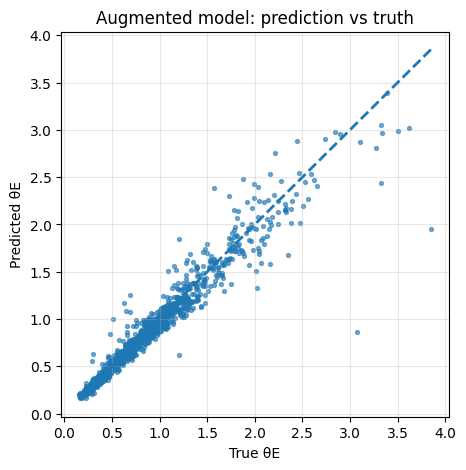

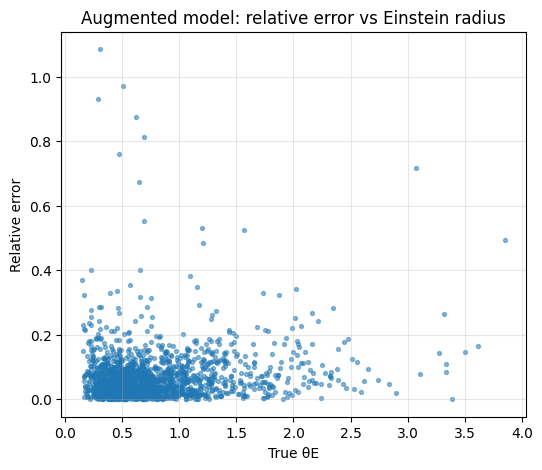

In [46]:
plt.figure(figsize=(5,5))
plt.scatter(y_true_test, y_pred_test, s=8, alpha=0.6)
mn, mx = min(y_true_test.min(), y_pred_test.min()), max(y_true_test.max(), y_pred_test.max())
plt.plot([mn, mx], [mn, mx], "--", linewidth=2)
plt.xlabel("True θE")
plt.ylabel("Predicted θE")
plt.title("Augmented model: prediction vs truth")
plt.grid(alpha=0.3)
plt.show()

err = y_pred_test - y_true_test
rel_err = np.abs(err) / y_true_test

plt.figure(figsize=(6,5))
plt.scatter(y_true_test, rel_err, s=8, alpha=0.5)
plt.xlabel("True θE")
plt.ylabel("Relative error")
plt.title("Augmented model: relative error vs Einstein radius")
plt.grid(alpha=0.3)
plt.show()
